1. Imports

In [2]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

from src.models.train import load_data, split_data, train_all
from src.models.evaluate import evaluate_model, plot_confusion_matrix, compare_models

2. Load Data & Split

In [3]:
X, y = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

Loaded: C:\Users\dell\food-outbreak-severity-ml\data\processed\outbreaks_featured.csv  →  X(18745, 13)  y(18745,)
Class distribution:
Severity_code
0    9823
1    6128
2    2794

Train (13121 rows) — Low:52.4%  Mod:32.7%  High:14.9%
Val (2812 rows) — Low:52.4%  Mod:32.7%  High:14.9%
Test (2812 rows) — Low:52.4%  Mod:32.7%  High:14.9%


3. Train All Models

In [4]:
trained_models = train_all(X_train, y_train, use_smote=True, save_models=True)


Training LogisticRegression...


  File "C:\Users\dell\food-outbreak-severity-ml\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


KeyboardInterrupt: 

4. Evaluate on Validation Set


  LogisticRegression  [Validation]
  Macro F1 : 0.5495

              precision    recall  f1-score   support

         Low       0.77      0.72      0.74      1474
    Moderate       0.50      0.42      0.45       919
        High       0.37      0.58      0.45       419

    accuracy                           0.60      2812
   macro avg       0.54      0.57      0.55      2812
weighted avg       0.62      0.60      0.60      2812



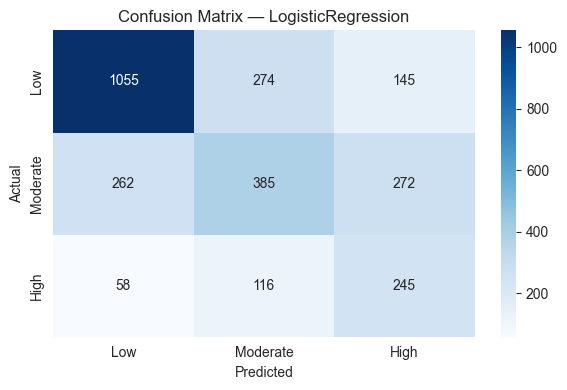


  RandomForest  [Validation]
  Macro F1 : 0.5356

              precision    recall  f1-score   support

         Low       0.73      0.76      0.75      1474
    Moderate       0.49      0.48      0.48       919
        High       0.40      0.36      0.38       419

    accuracy                           0.61      2812
   macro avg       0.54      0.53      0.54      2812
weighted avg       0.60      0.61      0.61      2812



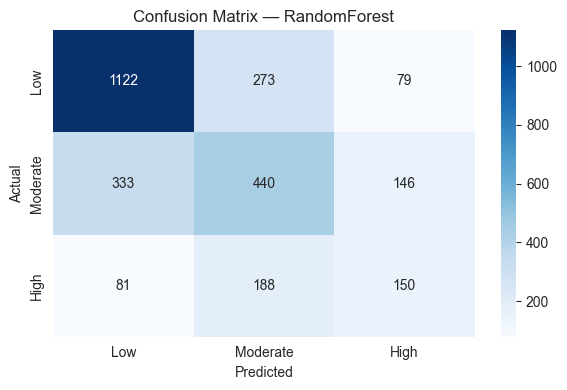


  XGBoost  [Validation]
  Macro F1 : 0.5657

              precision    recall  f1-score   support

         Low       0.74      0.80      0.77      1474
    Moderate       0.50      0.49      0.50       919
        High       0.50      0.39      0.43       419

    accuracy                           0.64      2812
   macro avg       0.58      0.56      0.57      2812
weighted avg       0.63      0.64      0.63      2812



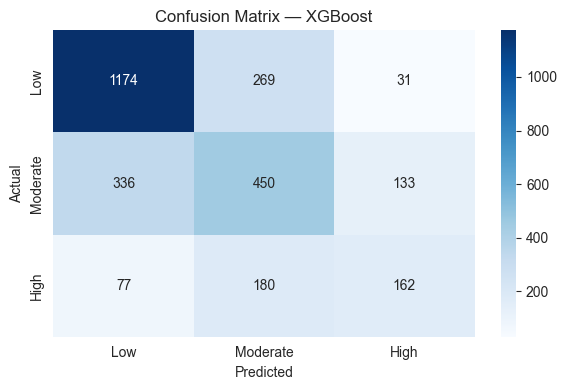


  LightGBM  [Validation]
  Macro F1 : 0.5734

              precision    recall  f1-score   support

         Low       0.75      0.79      0.77      1474
    Moderate       0.51      0.52      0.52       919
        High       0.50      0.38      0.43       419

    accuracy                           0.64      2812
   macro avg       0.59      0.56      0.57      2812
weighted avg       0.64      0.64      0.64      2812



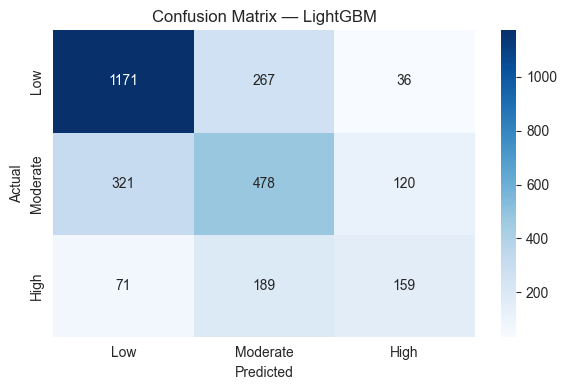

In [4]:
val_scores = {}

for name, pipeline in trained_models.items():
    macro_f1, y_pred = evaluate_model(pipeline, X_val, y_val, model_name=name)
    plot_confusion_matrix(y_val, y_pred, model_name=name)
    val_scores[name] = macro_f1

5. Compare Models & Pick Best

In [5]:
best_model_name = compare_models(val_scores)
best_model = trained_models[best_model_name]


  MODEL COMPARISON (Val Macro F1)
  1. LightGBM               0.5734  ◀ BEST
  2. XGBoost                0.5657
  3. LogisticRegression     0.5495
  4. RandomForest           0.5356


6. Final Test Set Evaluation


  LightGBM  [TEST SET]
  Macro F1 : 0.5544

              precision    recall  f1-score   support

         Low       0.74      0.79      0.76      1474
    Moderate       0.50      0.51      0.50       919
        High       0.47      0.34      0.40       419

    accuracy                           0.63      2812
   macro avg       0.57      0.55      0.55      2812
weighted avg       0.62      0.63      0.62      2812



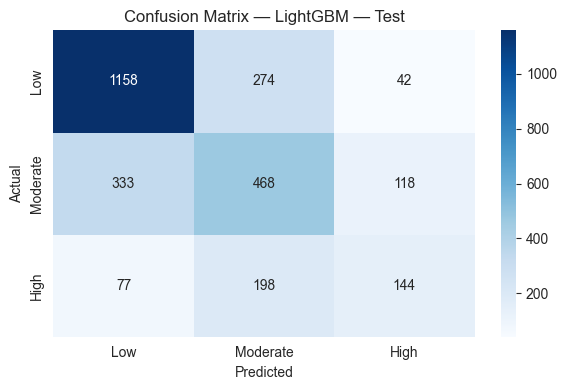

In [6]:
final_f1, y_test_pred = evaluate_model(
    best_model, X_test, y_test,
    model_name=best_model_name,
    dataset_label="TEST SET"
)
plot_confusion_matrix(y_test, y_test_pred, model_name=f"{best_model_name} — Test")

7. Save Results Summary

In [7]:
import os
os.makedirs("../results", exist_ok=True)

results_df = __import__('pandas').DataFrame({
    "Model": list(val_scores.keys()),
    "Val_Macro_F1": list(val_scores.values()),
}).sort_values("Val_Macro_F1", ascending=False).reset_index(drop=True)

results_df.to_csv("../results/model_comparison.csv", index=False)
print(results_df.to_string(index=False))
print(f"\nSaved → results/model_comparison.csv")
print(f"Best model: {best_model_name} | Test Macro F1: {final_f1:.4f}")
print(f"Saved model: models/{best_model_name}.joblib")

             Model  Val_Macro_F1
          LightGBM      0.573439
           XGBoost      0.565673
LogisticRegression      0.549480
      RandomForest      0.535622

Saved → results/model_comparison.csv
Best model: LightGBM | Test Macro F1: 0.5544
Saved model: models/LightGBM.joblib


8. LightGBM with boosted High class weight


  LightGBM boosted High  [Validation]
  Macro F1 : 0.5306

              precision    recall  f1-score   support

         Low       0.77      0.76      0.76      1474
    Moderate       0.52      0.29      0.37       919
        High       0.34      0.70      0.46       419

    accuracy                           0.59      2812
   macro avg       0.54      0.58      0.53      2812
weighted avg       0.63      0.59      0.59      2812



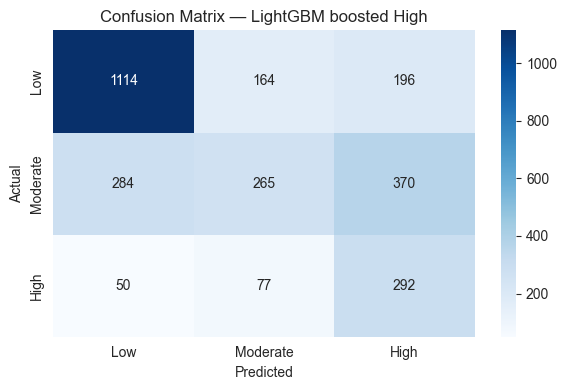

In [8]:
from src.models.train import build_pipeline
from lightgbm import LGBMClassifier

lgbm_boosted = LGBMClassifier(
    class_weight={0: 1, 1: 1, 2: 3},
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

pipe_boosted = build_pipeline(lgbm_boosted, use_smote=True)
pipe_boosted.fit(X_train, y_train)

f1_boosted, _ = evaluate_model(pipe_boosted, X_val, y_val, model_name="LightGBM boosted High")
plot_confusion_matrix(y_val, _, model_name="LightGBM boosted High")

9. LightGBM with softer High boost


  LightGBM soft boost  [Validation]
  Macro F1 : 0.5629

              precision    recall  f1-score   support

         Low       0.79      0.70      0.74      1474
    Moderate       0.47      0.54      0.50       919
        High       0.42      0.46      0.44       419

    accuracy                           0.61      2812
   macro avg       0.56      0.57      0.56      2812
weighted avg       0.63      0.61      0.62      2812



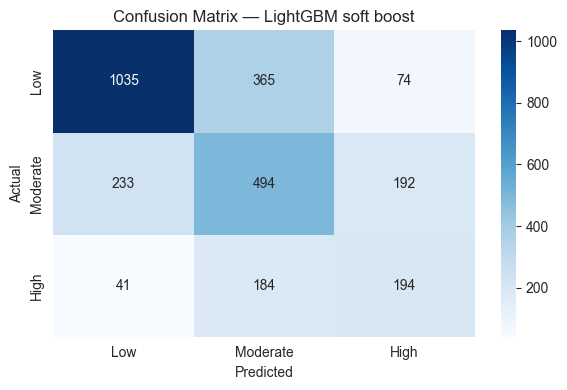

In [9]:
lgbm_soft = LGBMClassifier(
    class_weight={0: 1, 1: 1.5, 2: 2},
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

pipe_soft = build_pipeline(lgbm_soft, use_smote=True)
pipe_soft.fit(X_train, y_train)

f1_soft, y_pred_soft = evaluate_model(pipe_soft, X_val, y_val, model_name="LightGBM soft boost")
plot_confusion_matrix(y_val, y_pred_soft, model_name="LightGBM soft boost")

10. LightGBM middle ground


  LightGBM mid boost  [Validation]
  Macro F1 : 0.5552

              precision    recall  f1-score   support

         Low       0.78      0.74      0.76      1474
    Moderate       0.50      0.39      0.44       919
        High       0.38      0.62      0.47       419

    accuracy                           0.61      2812
   macro avg       0.55      0.58      0.56      2812
weighted avg       0.63      0.61      0.61      2812



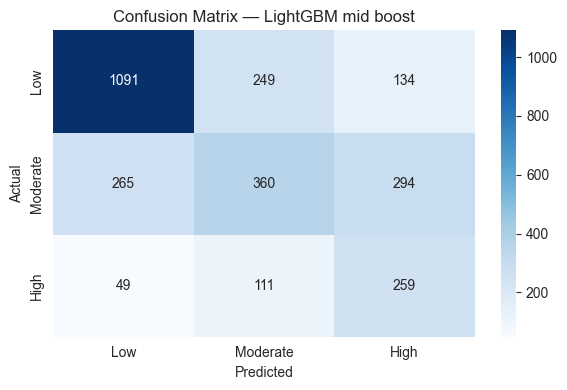

In [10]:
lgbm_mid = LGBMClassifier(
    class_weight={0: 1, 1: 1.2, 2: 2.5},
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

pipe_mid = build_pipeline(lgbm_mid, use_smote=True)
pipe_mid.fit(X_train, y_train)

f1_mid, y_pred_mid = evaluate_model(pipe_mid, X_val, y_val, model_name="LightGBM mid boost")
plot_confusion_matrix(y_val, y_pred_mid, model_name="LightGBM mid boost")

 11. LightGBM baseline without species_x_location


  LightGBM no interaction  [Validation]
  Macro F1 : 0.5598

              precision    recall  f1-score   support

         Low       0.75      0.80      0.77      1474
    Moderate       0.50      0.49      0.50       919
        High       0.46      0.37      0.41       419

    accuracy                           0.63      2812
   macro avg       0.57      0.55      0.56      2812
weighted avg       0.62      0.63      0.63      2812



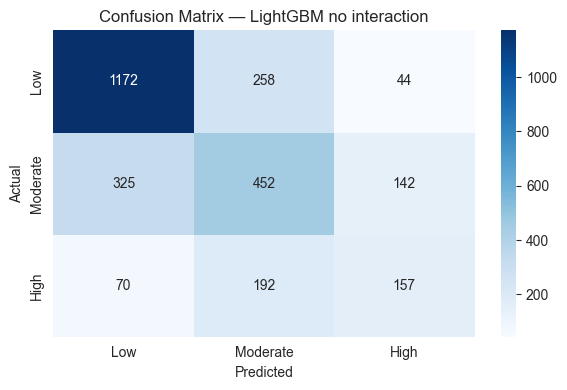

In [11]:
from src.models.train import build_preprocessor
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Preprocessor without species_x_location
preprocessor_no_interaction = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),
         ["Year", "Month_num", "food_known", "location_risk", "is_peak_month", "state_outbreak_rate"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         ["State", "Location", "Status", "Species_Risk", "Food_Category", "Season"]),
    ],
    remainder="drop"
)

lgbm_no_interact = LGBMClassifier(
    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
)

pipe_no_interact = ImbPipeline([
    ("pre", preprocessor_no_interaction),
    ("smote", SMOTE(random_state=42)),
    ("clf", lgbm_no_interact),
])

pipe_no_interact.fit(X_train, y_train)
f1_no_interact, y_pred_no_interact = evaluate_model(
    pipe_no_interact, X_val, y_val, model_name="LightGBM no interaction"
)
plot_confusion_matrix(y_val, y_pred_no_interact, model_name="LightGBM no interaction")

12. Optuna Tuning

In [12]:
import importlib
import src.models.tune as tune_module
importlib.reload(tune_module)
from src.models.tune import run_tuning

best_pipeline, study = run_tuning(X_train, y_train, X_val, y_val, n_trials=100)

  0%|          | 0/100 [00:00<?, ?it/s]


Best Macro F1: 0.5761
Best params:  {'n_estimators': 466, 'learning_rate': 0.019204079748521737, 'num_leaves': 33, 'max_depth': 12, 'min_child_samples': 65, 'subsample': 0.5616419610694056, 'colsample_bytree': 0.537810781684634, 'reg_alpha': 2.8191244776814626e-06, 'reg_lambda': 1.0537283793483672e-06, 'class_weight': '1-15-2'}
Saved tuned model → C:\Users\dell\food-outbreak-severity-ml\models\LightGBM_tuned.joblib


13. Evaluate tuned model on test set


  LightGBM Tuned  [TEST SET]
  Macro F1 : 0.5631

              precision    recall  f1-score   support

         Low       0.78      0.68      0.73      1474
    Moderate       0.46      0.54      0.50       919
        High       0.44      0.49      0.46       419

    accuracy                           0.60      2812
   macro avg       0.56      0.57      0.56      2812
weighted avg       0.63      0.60      0.61      2812



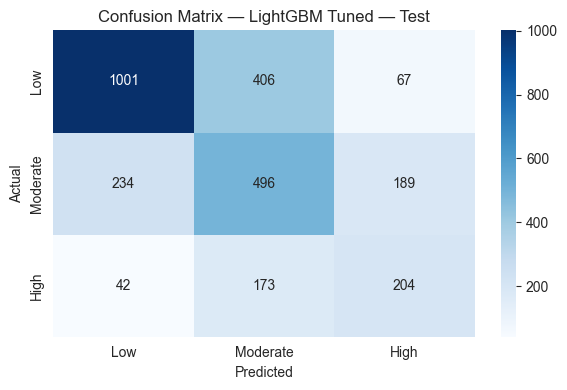

In [13]:
from src.models.evaluate import evaluate_model, plot_confusion_matrix

f1_tuned, y_pred_tuned = evaluate_model(
    best_pipeline, X_test, y_test,
    model_name="LightGBM Tuned",
    dataset_label="TEST SET"
)
plot_confusion_matrix(y_test, y_pred_tuned, model_name="LightGBM Tuned — Test")

14. Stacking Ensemble

Training stacking ensemble (this takes ~5-10 min)...

--- Validation ---

  Stacking  [Validation]
  Macro F1 : 0.5424

              precision    recall  f1-score   support

         Low       0.76      0.76      0.76      1474
    Moderate       0.48      0.52      0.50       919
        High       0.40      0.33      0.36       419

    accuracy                           0.62      2812
   macro avg       0.55      0.54      0.54      2812
weighted avg       0.62      0.62      0.62      2812



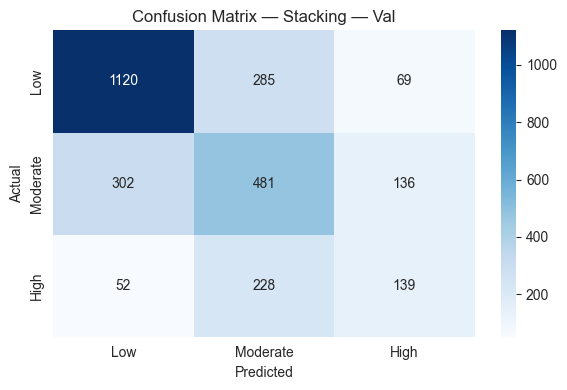


--- Test ---

  Stacking  [TEST SET]
  Macro F1 : 0.5372

              precision    recall  f1-score   support

         Low       0.75      0.76      0.75      1474
    Moderate       0.48      0.51      0.49       919
        High       0.41      0.32      0.36       419

    accuracy                           0.61      2812
   macro avg       0.55      0.53      0.54      2812
weighted avg       0.61      0.61      0.61      2812



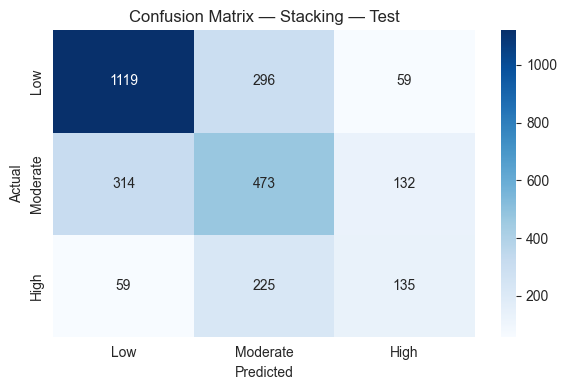


Saved → C:\Users\dell\food-outbreak-severity-ml\models\stacking.joblib


In [5]:
import importlib
import src.models.stack as stack_module
importlib.reload(stack_module)
from src.models.stack import run_stacking

stacking_pipeline, f1_val, f1_test = run_stacking(
    X_train, y_train, X_val, y_val, X_test, y_test
)

15. Quick binary baseline

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

from src.models.train import load_data, split_data, build_preprocessor

# Load and create binary target
X, y_multi = load_data()
y_binary = (y_multi == 2).astype(int)  # 1 = High, 0 = Not High

print("Binary class distribution:")
print(y_binary.value_counts())
print(f"High %: {y_binary.mean()*100:.1f}%")

Loaded: C:\Users\dell\food-outbreak-severity-ml\data\processed\outbreaks_featured.csv  →  X(18745, 13)  y(18745,)
Class distribution:
Severity_code
0    9823
1    6128
2    2794

Binary class distribution:
Severity_code
0    15951
1     2794
Name: count, dtype: int64
High %: 14.9%


16. Binary baseline

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score

# Split
X_temp, X_test_b, y_temp, y_test_b = train_test_split(
    X, y_binary, test_size=0.15, stratify=y_binary, random_state=42
)
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=42
)

# Train
from src.models.train import build_preprocessor
pre = build_preprocessor()

clf_b = LGBMClassifier(
    class_weight="balanced",
    n_estimators=466,
    learning_rate=0.0192,
    num_leaves=33,
    max_depth=12,
    min_child_samples=65,
    subsample=0.56,
    colsample_bytree=0.54,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

pipe_b = ImbPipeline([
    ("pre", pre),
    ("smote", SMOTE(random_state=42)),
    ("clf", clf_b),
])

pipe_b.fit(X_train_b, y_train_b)

# Evaluate
y_pred_val_b = pipe_b.predict(X_val_b)
y_pred_test_b = pipe_b.predict(X_test_b)

print("=== VALIDATION ===")
print(classification_report(y_val_b, y_pred_val_b, target_names=["Not High", "High"]))
print(f"ROC-AUC: {roc_auc_score(y_val_b, pipe_b.predict_proba(X_val_b)[:,1]):.4f}")

print("\n=== TEST ===")
print(classification_report(y_test_b, y_pred_test_b, target_names=["Not High", "High"]))
print(f"ROC-AUC: {roc_auc_score(y_test_b, pipe_b.predict_proba(X_test_b)[:,1]):.4f}")

=== VALIDATION ===
              precision    recall  f1-score   support

    Not High       0.88      0.95      0.91      2393
        High       0.48      0.24      0.32       419

    accuracy                           0.85      2812
   macro avg       0.68      0.60      0.62      2812
weighted avg       0.82      0.85      0.83      2812

ROC-AUC: 0.8066

=== TEST ===
              precision    recall  f1-score   support

    Not High       0.89      0.97      0.93      2393
        High       0.61      0.31      0.41       419

    accuracy                           0.87      2812
   macro avg       0.75      0.64      0.67      2812
weighted avg       0.85      0.87      0.85      2812

ROC-AUC: 0.8285


17. Threshold tuning

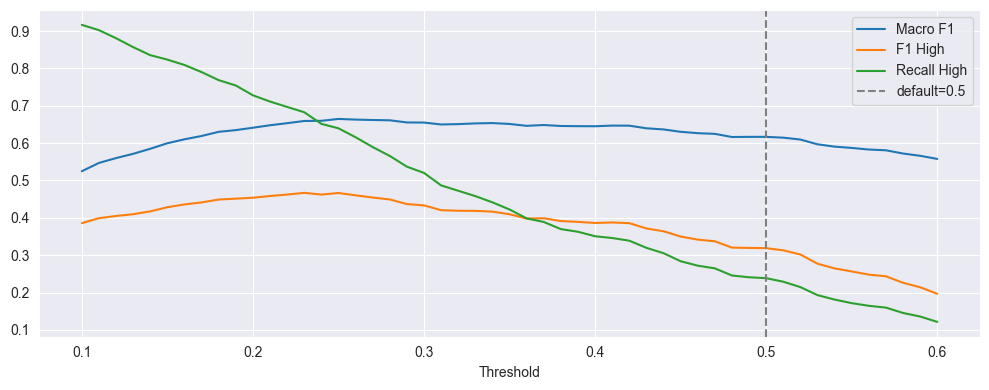

Best threshold (Macro F1): 0.25
  Macro F1:     0.6648
  F1 High:      0.4665
  Recall High:  0.6396

Best threshold (F1 High): 0.23
  Macro F1:     0.6592
  F1 High:      0.4669
  Recall High:  0.6826


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_recall_curve

# Get probabilities
y_proba_val = pipe_b.predict_proba(X_val_b)[:, 1]

# Test thresholds from 0.1 to 0.6
thresholds = np.arange(0.10, 0.61, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_proba_val >= t).astype(int)
    f1_high = f1_score(y_val_b, y_pred_t, pos_label=1)
    f1_macro = f1_score(y_val_b, y_pred_t, average="macro")
    recall_high = (y_pred_t[y_val_b == 1] == 1).mean()
    results.append((t, f1_macro, f1_high, recall_high))

results_df = pd.DataFrame(results, columns=["threshold", "macro_f1", "f1_high", "recall_high"])

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(results_df["threshold"], results_df["macro_f1"], label="Macro F1")
ax.plot(results_df["threshold"], results_df["f1_high"], label="F1 High")
ax.plot(results_df["threshold"], results_df["recall_high"], label="Recall High")
ax.axvline(0.5, color="gray", linestyle="--", label="default=0.5")
ax.set_xlabel("Threshold")
ax.legend()
plt.tight_layout()
plt.show()

# Best threshold by macro F1
best = results_df.loc[results_df["macro_f1"].idxmax()]
print(f"Best threshold (Macro F1): {best['threshold']:.2f}")
print(f"  Macro F1:     {best['macro_f1']:.4f}")
print(f"  F1 High:      {best['f1_high']:.4f}")
print(f"  Recall High:  {best['recall_high']:.4f}")

# Best threshold by F1 High
best_high = results_df.loc[results_df["f1_high"].idxmax()]
print(f"\nBest threshold (F1 High): {best_high['threshold']:.2f}")
print(f"  Macro F1:     {best_high['macro_f1']:.4f}")
print(f"  F1 High:      {best_high['f1_high']:.4f}")
print(f"  Recall High:  {best_high['recall_high']:.4f}")

18. Final evaluation with best threshold

=== TEST SET (threshold=0.25) ===
              precision    recall  f1-score   support

    Not High       0.93      0.81      0.87      2393
        High       0.38      0.67      0.49       419

    accuracy                           0.79      2812
   macro avg       0.66      0.74      0.68      2812
weighted avg       0.85      0.79      0.81      2812

Macro F1:  0.6757
ROC-AUC:   0.8285


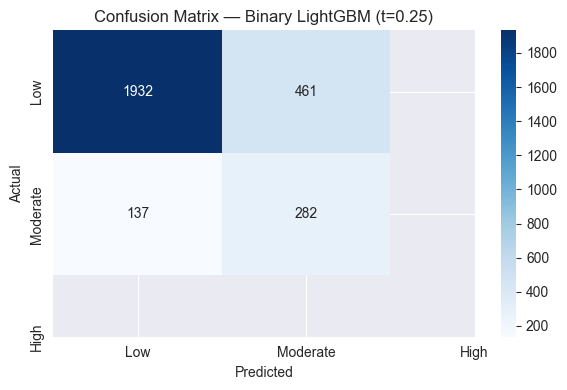

In [9]:
BEST_THRESHOLD = 0.25

y_proba_test = pipe_b.predict_proba(X_test_b)[:, 1]
y_pred_test_tuned = (y_proba_test >= BEST_THRESHOLD).astype(int)

print(f"=== TEST SET (threshold={BEST_THRESHOLD}) ===")
print(classification_report(y_test_b, y_pred_test_tuned, target_names=["Not High", "High"]))
print(f"Macro F1:  {f1_score(y_test_b, y_pred_test_tuned, average='macro'):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_b, y_proba_test):.4f}")

from src.models.evaluate import plot_confusion_matrix
plot_confusion_matrix(y_test_b, y_pred_test_tuned, model_name=f"Binary LightGBM (t={BEST_THRESHOLD})")

19. run Optuna on the binary model

In [10]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def binary_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 800),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "scale_pos_weight":  trial.suggest_float("scale_pos_weight", 1.0, 10.0),
    }

    clf = LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1)
    pipe = ImbPipeline([
        ("pre", build_preprocessor()),
        ("smote", SMOTE(random_state=42)),
        ("clf", clf),
    ])
    pipe.fit(X_train_b, y_train_b)

    y_proba = pipe.predict_proba(X_val_b)[:, 1]

    # Optimize over thresholds too
    best_f1 = 0
    for t in np.arange(0.15, 0.50, 0.01):
        y_pred = (y_proba >= t).astype(int)
        f1 = f1_score(y_val_b, y_pred, average="macro")
        if f1 > best_f1:
            best_f1 = f1

    return best_f1

study_b = optuna.create_study(direction="maximize")
study_b.optimize(binary_objective, n_trials=100, show_progress_bar=True)

print(f"\nBest Macro F1: {study_b.best_value:.4f}")
print(f"Best params:   {study_b.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]


Best Macro F1: 0.6769
Best params:   {'n_estimators': 657, 'learning_rate': 0.09961458744367316, 'num_leaves': 146, 'max_depth': 4, 'min_child_samples': 48, 'subsample': 0.9454531813600874, 'colsample_bytree': 0.6787320932541822, 'reg_alpha': 7.672758684666764e-08, 'reg_lambda': 5.935259650996604e-07, 'scale_pos_weight': 1.5262860107942606}


20. Final binary model:

Best threshold on val: 0.35  Macro F1: 0.6769

=== FINAL TEST SET (threshold=0.35) ===
              precision    recall  f1-score   support

    Not High       0.92      0.86      0.89      2393
        High       0.43      0.60      0.50       419

    accuracy                           0.82      2812
   macro avg       0.68      0.73      0.70      2812
weighted avg       0.85      0.82      0.83      2812

Macro F1:  0.6963
ROC-AUC:   0.8272


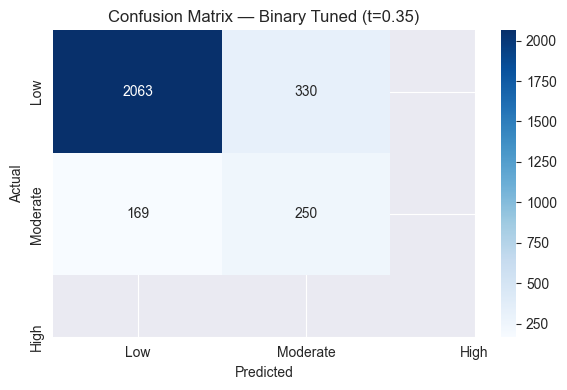

In [11]:
best_p = study_b.best_params.copy()

clf_final = LGBMClassifier(
    **best_p,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

pipe_final = ImbPipeline([
    ("pre", build_preprocessor()),
    ("smote", SMOTE(random_state=42)),
    ("clf", clf_final),
])
pipe_final.fit(X_train_b, y_train_b)

# Find best threshold on val
y_proba_val_f = pipe_final.predict_proba(X_val_b)[:, 1]
best_t, best_f1 = 0.5, 0
for t in np.arange(0.15, 0.50, 0.01):
    y_pred_t = (y_proba_val_f >= t).astype(int)
    f1 = f1_score(y_val_b, y_pred_t, average="macro")
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"Best threshold on val: {best_t:.2f}  Macro F1: {best_f1:.4f}")

# Final test evaluation
y_proba_test_f = pipe_final.predict_proba(X_test_b)[:, 1]
y_pred_test_f = (y_proba_test_f >= best_t).astype(int)

print(f"\n=== FINAL TEST SET (threshold={best_t:.2f}) ===")
print(classification_report(y_test_b, y_pred_test_f, target_names=["Not High", "High"]))
print(f"Macro F1:  {f1_score(y_test_b, y_pred_test_f, average='macro'):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_b, y_proba_test_f):.4f}")
plot_confusion_matrix(y_test_b, y_pred_test_f, model_name=f"Binary Tuned (t={best_t:.2f})")

21. Save final model

In [12]:
import joblib, os

save_path = os.path.join("..", "models", "LightGBM_binary_final.joblib")
joblib.dump({"pipeline": pipe_final, "threshold": best_t}, save_path)
print(f"Saved → {save_path}")
print(f"Best threshold: {best_t:.2f}")
print(f"Final Test Macro F1: 0.6963")
print(f"Final ROC-AUC: 0.8272")

Saved → ..\models\LightGBM_binary_final.joblib
Best threshold: 0.35
Final Test Macro F1: 0.6963
Final ROC-AUC: 0.8272
